In [11]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [12]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [13]:
NUM_CLASSES = 41

# Dataset reading

In [14]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [15]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [17]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [18]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)                  │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 41)                  │             451 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,521 (5.94 KB)

 Trainable params: 1,521 (5.94 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [20]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [21]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
16/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0885 - loss: 3.7410
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0920 - loss: 3.7276 - val_accuracy: 0.0912 - val_loss: 3.5817
Epoch 2/1000
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1308 - loss: 3.5572  
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1314 - loss: 3.5529 - val_accuracy: 0.1505 - val_loss: 3.3801
Epoch 3/1000
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1562 - loss: 3.3463 
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1567 - loss: 3.3393 - val_accuracy: 0.1505 - val_loss: 3.0705
Epoch 4/1000
 1/22 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.1250 - loss: 3.1738
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.ker

In [22]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0232 


In [23]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [24]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[8.6850571e-03 8.9282340e-01 3.6349839e-03 6.1560308e-09 9.3535140e-02
 2.1709183e-09 8.5401717e-07 5.3067016e-08 1.3132705e-03 7.1054333e-06
 5.5583717e-13 5.9949229e-12 1.1368738e-13 1.7751452e-14 1.6073469e-12
 4.0801971e-12 2.6056953e-11 2.7146338e-13 2.2742985e-14 3.0825085e-13
 4.9690886e-14 4.7854228e-13 3.4722876e-13 5.3352496e-12 3.1720278e-13
 1.6552820e-12 7.0177505e-12 6.8215035e-13 3.3302679e-12 5.2034691e-14
 4.2842001e-11 8.4270806e-13 1.5515406e-14 6.5437803e-13 2.9500319e-12
 1.1370971e-13 3.0551486e-14 2.1458408e-11 7.6456472e-15 1.5138210e-12
 3.0971772e-13]
1


# Confusion matrix

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


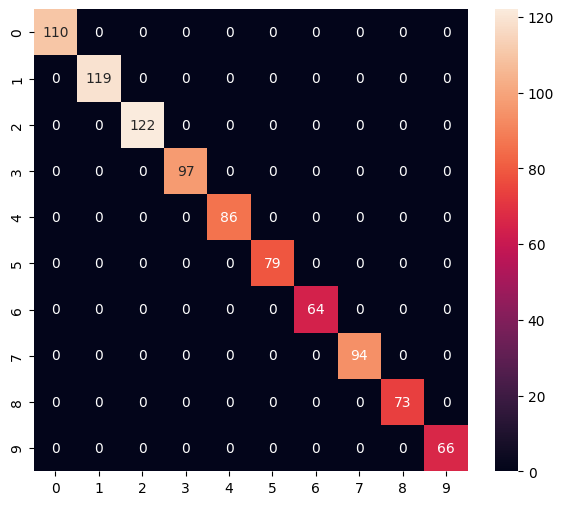

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       119
           2       1.00      1.00      1.00       122
           3       1.00      1.00      1.00        97
           4       1.00      1.00      1.00        86
           5       1.00      1.00      1.00        79
           6       1.00      1.00      1.00        64
           7       1.00      1.00      1.00        94
           8       1.00      1.00      1.00        73
           9       1.00      1.00      1.00        66

    accuracy                           1.00       910
   macro avg       1.00      1.00      1.00       910
weighted avg       1.00      1.00      1.00       910



In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [26]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [ ]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\bayan\AppData\Local\Temp\tmpu1knmy8j\assets


INFO:tensorflow:Assets written to: C:\Users\bayan\AppData\Local\Temp\tmpu1knmy8j\assets


# Inference test

In [1]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

NameError: name 'tf' is not defined

In [ ]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))